In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\Pradhuman\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
df = pd.read_csv('wine_data.csv',header=None , usecols=[0,1,2])

print(df.info())
print('\n')
print(df.head())

df.columns = ['class_label','alcohol','malic_acid']

print(f"After renaming Columns\n{df.head()}")

<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       178 non-null    int64  
 1   1       178 non-null    float64
 2   2       178 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 4.3 KB
None


   0      1     2
0  1  14.23  1.71
1  1  13.20  1.78
2  1  13.16  2.36
3  1  14.37  1.95
4  1  13.24  2.59
After renaming Columns
   class_label  alcohol  malic_acid
0            1    14.23        1.71
1            1    13.20        1.78
2            1    13.16        2.36
3            1    14.37        1.95
4            1    13.24        2.59


**EDA ON Features**

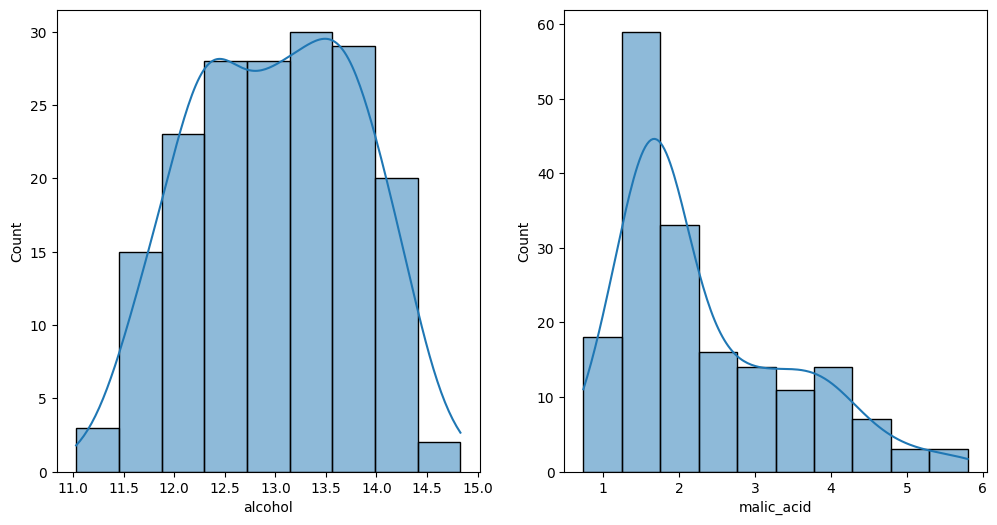

In [ ]:
# (i) Histogram + Kdeplot
fig , ax = plt.subplots(ncols=2 , figsize=(12,6))
sns.histplot(df['alcohol'] , ax = ax[0] , kde=True)
sns.histplot(df['malic_acid'] , ax=ax[1] , kde=True)
plt.show()

<Axes: xlabel='alcohol', ylabel='malic_acid'>

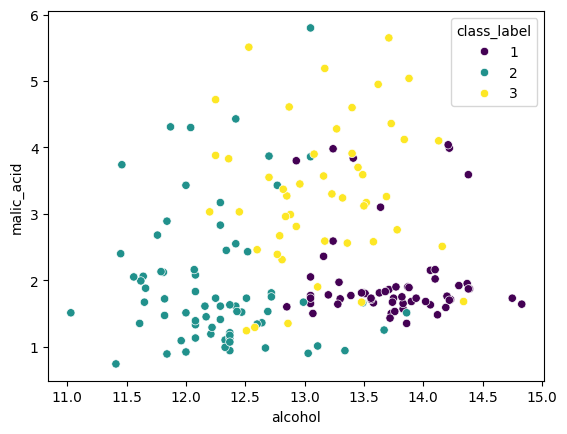

In [11]:
# Let us plot the data 
sns.scatterplot(x = df['alcohol'] , y = df['malic_acid'],hue=df['class_label'] , palette = 'viridis')

In [8]:
# Let us split the data into training and Testing set
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.iloc[:,1:] , df.iloc[:,0] , test_size = .3 , random_state =42)

In [9]:
print(f"X_train -> {X_train.shape}")
print(f"X_test -> {X_test.shape}")
print(f"y_train -> {y_train.shape}")
print(f"y_tset -> {y_test.shape}")

X_train -> (124, 2)
X_test -> (54, 2)
y_train -> (124,)
y_tset -> (54,)


In [13]:
# Let us first Normalize our data using MinMaxScaling
from sklearn.preprocessing import MinMaxScaler, RobustScaler
min_max_scale  =MinMaxScaler()
robust_scale = RobustScaler()

# Scaling the Features with MinMax Scaler
X_train_mm_scaled = pd.DataFrame(min_max_scale.fit_transform(X_train) , columns = X_train.columns)
X_test_mm_scaled = pd.DataFrame(min_max_scale.transform(X_test) , columns = X_test.columns)

# Scaling the Features with Robust Scaler
X_train_rc_scaled = pd.DataFrame(robust_scale.fit_transform(X_train) , columns = X_train.columns)
X_test_rc_scaled = pd.DataFrame(robust_scale.transform(X_test) , columns = X_test.columns)

In [ ]:
# Let us now fit the Logistic Regression Model and check the Evalutaion
from sklearn.linear_model import LogisticRegression


lr = LogisticRegression(max_iter=1000) # Creating model object
model = lr.fit(X_train , y_train) # Fitting the model on unscaled data
y_pred = model.predict(X_test) # predicting the Test Output without scaling



lr_mm_scaled = LogisticRegression(max_iter=1000)
model_mm_scaled = lr.fit(X_train_mm_scaled , y_train) # Fitting the model on MinMax Scaled  data
y_pred_mm_scaled = model_mm_scaled.predict(X_test_mm_scaled) # predicting the Test Output After MinMax Scaling scaling



lr_rc_scaled = LogisticRegression(max_iter=1000)
model_rc_scaled = lr.fit(X_train_rc_scaled , y_train) # Fitting the model on Robust Scaled  data
y_pred_rc_scaled = model_rc_scaled.predict(X_test_rc_scaled) # predicting the Test Output After Robust Scaling scaling




In [18]:
# ----------- Evaluation And Comparison ------------------

from sklearn.metrics import accuracy_score , classification_report
print(f"\tWithout Scaling Accuracy Score->\n{accuracy_score(y_test , y_pred)}\n")
print(f"\tMinMax Scaling Accuracy Score->\n{accuracy_score(y_test , y_pred_mm_scaled)}\n")
print(f"\tRobust Scaling Accuracy Score->\n{accuracy_score(y_test , y_pred_rc_scaled)}\n")

	Without Scaling Accuracy Score->
0.7407407407407407

	MinMax Scaling Accuracy Score->
0.7407407407407407

	Robust Scaling Accuracy Score->
0.7407407407407407



### We do not see any changes in the accuracy score of the data -> But that does not mean that Scaling was Not required

### Scaling helps the data to comes in the same numeric range and helps the model train better 

In [19]:
print(f"\tWithout Scaling Classification Report->\n{classification_report(y_test , y_pred)}\n")
print(f"\tMinMax Scaling Classification Report->\n{classification_report(y_test , y_pred_mm_scaled)}\n")
print(f"\tRobust Scaling Classification Report->\n{classification_report(y_test , y_pred_rc_scaled)}\n")

	Without Scaling Classification Report->
              precision    recall  f1-score   support

           1       0.70      0.84      0.76        19
           2       0.89      0.76      0.82        21
           3       0.62      0.57      0.59        14

    accuracy                           0.74        54
   macro avg       0.73      0.73      0.73        54
weighted avg       0.75      0.74      0.74        54


	MinMax Scaling Classification Report->
              precision    recall  f1-score   support

           1       0.73      0.84      0.78        19
           2       0.81      0.81      0.81        21
           3       0.64      0.50      0.56        14

    accuracy                           0.74        54
   macro avg       0.72      0.72      0.72        54
weighted avg       0.74      0.74      0.73        54


	Robust Scaling Classification Report->
              precision    recall  f1-score   support

           1       0.70      0.84      0.76        19
      

### ***CONCLUSION***

- Since the data was fairly even between the Features
- That is why The model results were almost identical when we modelled without scaling, using MinMaxScaler and using RobustScaler